# challange 9- least squares

#### in class least squares notes:

what do we do when there is no solution we can find? 
how to we predict where the data is leading us?
looking ofr the BEST FIT LINE

what is least squares? --> tool in numarical analysis and data fitting
   -  we have more data points than paremters
   - we want to minimize the overall error
   - we want to minimize the sum of the SQUARED RISIDUALS (risuals -> r=y-(mx+c))
           - what does the square do? it emphasized the large errors and turns everything posiitve
           
           
Normal equations 
- how do we mininminse the residuals?
- take partial derivitives of S(m,c) with respect to m and c and set those equal to 0 -> this gives us a system of equations


Assumpotions:
- linear relationship between input vars and out put
- errors of independent
- errors are normal distributions
- homoscedastity - variance of residuals are constatnt across 

if these are violated - estimates are bias

In [1]:
#Imports 
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
import numpy as np

# Data points
X = np.array([1, 2, 3, 4, 5])
Y = np.array([1.2, 2.8, 3.6, 4.5, 5.1])

# Stack the design matrix with a column of ones (for the intercept) 
A = np.vstack([X, np.ones(len(X))]).T

print("X: ")
print(X)

print("Y: ")
print(Y)

print("A: ")
print(A)

# the one is representing all the intercept points as a intial guess



X: 
[1 2 3 4 5]
Y: 
[1.2 2.8 3.6 4.5 5.1]
A: 
[[1. 1.]
 [2. 1.]
 [3. 1.]
 [4. 1.]
 [5. 1.]]


In [3]:
# Solve using least squares
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
print(f"Slope: {m}, Intercept: {c}")

Slope: 0.9500000000000001, Intercept: 0.5900000000000001


### Plot the points and the output solution

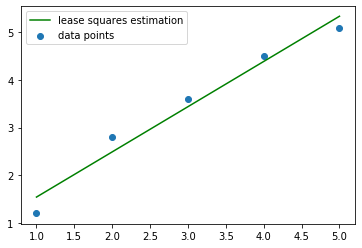

In [4]:
import matplotlib.pyplot as plt

ysol = m*X + c
plt.scatter(X,Y, label="data points")
plt.plot(X,ysol,'g', label= "lease squares estimation")
plt.legend()
plt.show()


### playing this random points:

In [5]:
import random

rng = np.random.default_rng(seed=42)

X = rng.uniform(5, 10, size=5)   # 5 floats in [5, 10)
X.sort()                         # optional: sort them
Y = rng.uniform(5, 10, size=5)   # 5 floats in [5, 10)

# Stack the design matrix with a column of ones (for the intercept) 
A = np.vstack([X, np.ones(len(X))]).T

print("X: ")
print(X)

print("Y: ")
print(Y)

print("A: ")
print(A)

X: 
[5.47088674 7.1943922  8.48684015 8.86978024 9.2929896 ]
Y: 
[9.87811176 8.80569851 8.93032153 5.64056816 7.25192969]
A: 
[[5.47088674 1.        ]
 [7.1943922  1.        ]
 [8.48684015 1.        ]
 [8.86978024 1.        ]
 [9.2929896  1.        ]]


Slope: -0.8210686408723734, Intercept: 14.557370412751427


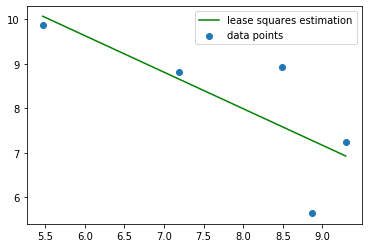

In [6]:
# Solve using least squares
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
print(f"Slope: {m}, Intercept: {c}")


ysol = m*X + c
plt.scatter(X,Y, label="data points")
plt.plot(X,ysol,'g', label= "lease squares estimation")
plt.legend()
plt.show()


### Adding in a small ranodm error to see how it effects

Slope: -0.8210686408723734, Intercept: 14.557370412751427


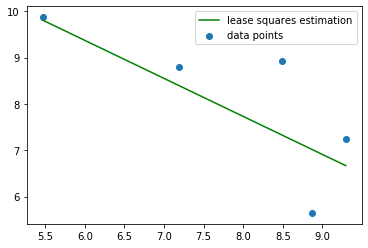

In [7]:
# Solve using least squares
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
print(f"Slope: {m}, Intercept: {c}")


ysol = m*X + c + rng.uniform(-1,1) ## add in a little error to c
plt.scatter(X,Y, label="data points")
plt.plot(X,ysol,'g', label= "lease squares estimation")
plt.legend()
plt.show()


### going the other direction --> starting from a line, adding a small error and then seeing if we can get the lien back!

True line:      y = 8.535299776972035 x + 1.4386512008066452
Estimated line: y = 8.408073763140596 x + 1.460066217734907

first couple residuals:
[ 0.62410821 -0.13331436 -0.56439305  0.09157134 -0.88869146  0.64020863
  0.24954734  0.50366628 -0.302185    0.93143137]
Largest residual:
X = 0.9 Y = 10.058773754776926 res = 1.0314411502154819
Smallest residual:
X = 0.74 Y = 7.678527496268726 res = -0.003513306190221499


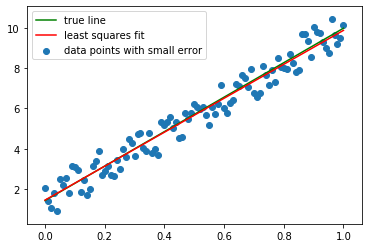

In [8]:
#making my own numbers
X = np.arange(0, 1.01, 0.01)
m_true = rng.uniform(-10, 10) 
b_true = rng.uniform(-5, 5)

y_true = m_true * X + b_true 

#adding in some error
err = rng.uniform(-1, 1, size=len(X)) 
Y = m_true * X + b_true + err

#estimated the errored data
A = np.vstack([X, np.ones(len(X))]).T
m_est, b_est = np.linalg.lstsq(A, Y, rcond=None)[0]
y_est = m_est*X + b_est

res = Y - y_est

#biggest and smallest abs residual
max_i = np.argmax(np.abs(res))
min_i = np.argmin(np.abs(res))

print("True line:      y =", m_true, "x +", b_true)
print("Estimated line: y =", m_est, "x +", b_est)
print()

print("first couple residuals:")
print(res[:10])

print("Largest residual:")
print("X =", X[max_i], "Y =", Y[max_i], "res =", res[max_i])

print("Smallest residual:")
print("X =", X[min_i], "Y =", Y[min_i], "res =", res[min_i])


#plotting to see how simulare the error estimates and the actual lines are
plt.plot(X, y_true, 'g', label="true line")
plt.scatter(X, Y, label="data points with small error")
plt.plot(X, y_est, 'r',label="least squares fit")
plt.legend()
plt.show()